In [ ]:
!mkdir -p ~/.kaggle

# Move kaggle.json to the correct folder
!mv kaggle.json ~/.kaggle/
!kaggle competitions download -c cognitive-profiling-prediction-action-recognition
!mkdir -p /content/kaggle_competition

In [ ]:
!unzip -q /content/cognitive-profiling-prediction-action-recognition.zip -d /content/kaggle_competition

In [ ]:
!pip install polars
!pip install ultralytics
!pip install torchinfo

In [66]:
'''
# Basic packages
conda install numpy pandas scikit-learn pillow matplotlib jupyter seaborn tqdm -y

# Polars (fast DataFrame lib)
pip install torch torchvision polars pyarrow opencv-python fastai ultralytics dtw-python

# imageio imageio-ffmpeg ultralytics
'''

import polars as pl
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.preprocessing import StandardScaler
import os
from ultralytics import YOLO
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from fastai.learner import Learner
from fastai.vision.all import *
from fastai.vision.all import PILImage
from dtw import dtw # Import the DTW library
from scipy.spatial.distance import euclidean 

# Abstract jeang photography

In [ ]:
import polars as pl
import numpy as np

colnum_names = [
    'subject',
    'timestamp',
    'frame',
    ] + [
        f'{point}_{postion}'
        for point in range(17)
        for postion in ['x', 'y', 'z']
        ] + [
            f'label_{label}'
            for label in range(12)
            ]


num_subject = 5
num_timestamp = 20
num_frame = 30

meta_data = [
    (s, t, f)
    for s in range(num_subject)
    for t in range(num_timestamp)
    for f in range(num_frame)
]

meta_array = np.array(meta_data)
num_rows = len(meta_array)
positions_array = np.random.randn(num_rows, 51).round(4)
label_array = np.random.randint(2, size=(num_rows, 12))
full_array = np.hstack([meta_array, positions_array, label_array]) #label_array
df = pl.DataFrame(full_array, schema=colnum_names)

df = df.with_columns([
    pl.col("subject").cast(pl.Int64),
    pl.col("timestamp").cast(pl.Int64),
    pl.col("frame").cast(pl.Int64),
])
df

#### test process

In [ ]:
df = df.drop(['subject', 'timestamp', 'frame'])
df = df.to_numpy()

In [ ]:
df

In [ ]:
# df = df.reshape((30, 3, 17))
df = df.reshape((30, 17, 3))

In [ ]:
df

In [ ]:
df.shape

In [ ]:
img = Image.fromarray(df, mode='RGB')
img

In [ ]:
img = img.resize((224, 224))
img

In [ ]:
mean = df.mean()
std = df.std()
standardized = (df - mean) / std

img = Image.fromarray(standardized, mode='RGB')
img = img.resize((224, 224))
img

## Data preprocess

In [73]:
train_df = pd.read_parquet('/project/ai901504-ai0004/501641_Big/week7/dataset/train_smiley_no_augment.parquet')
eval_df = pd.read_parquet('/project/ai901504-ai0004/501641_Big/week7/dataset/eval_smiley.parquet')

In [74]:
train_df.columns

Index(['Filename', 'minute', 'second', 'millisecond', 'pos_0_x', 'pos_0_y',
       'pos_1_x', 'pos_1_y', 'pos_2_x', 'pos_2_y', 'pos_3_x', 'pos_3_y',
       'pos_4_x', 'pos_4_y', 'pos_5_x', 'pos_5_y', 'pos_6_x', 'pos_6_y',
       'pos_7_x', 'pos_7_y', 'pos_8_x', 'pos_8_y', 'pos_9_x', 'pos_9_y',
       'pos_10_x', 'pos_10_y', 'pos_11_x', 'pos_11_y', 'pos_12_x', 'pos_12_y',
       'Time', 'Advancing', 'Retreating', 'Enclosing', 'Spreading', 'Rising',
       'Descending', 'Directing', 'Indirecting', 'Increasing Pressure',
       'Decreasing Pressure', 'Accelerating', 'Decelerating',
       'subject_timestamp_pair'],
      dtype='object')

In [75]:
train_df

,Filename,minute,second,millisecond,pos_0_x,pos_0_y,pos_1_x,pos_1_y,pos_2_x,pos_2_y,...,Spreading,Rising,Descending,Directing,Indirecting,Increasing Pressure,Decreasing Pressure,Accelerating,Decelerating,subject_timestamp_pair
0,s01_smiley,4,2,0,-1.345127,1.478502,-1.199554,1.533676,-0.669061,1.514326,...,1,0,0,0,0,0,1,0,1,"[s01_smiley, t0405]"
1,s01_smiley,4,2,120,-1.344440,1.479350,-1.202025,1.534529,-0.668743,1.517997,...,1,0,0,0,0,0,1,0,1,"[s01_smiley, t0405]"
2,s01_smiley,4,2,200,-1.378082,1.421112,-1.228520,1.483257,-0.686475,1.468258,...,1,0,0,0,0,0,1,0,1,"[s01_smiley, t0405]"
3,s01_smiley,4,2,320,-1.426917,1.499499,-1.280452,1.546347,-0.707275,1.526341,...,1,0,0,0,0,0,1,0,1,"[s01_smiley, t0405]"
4,s01_smiley,4,2,400,-1.453202,1.440369,-1.301744,1.488016,-0.726482,1.473405,...,1,0,0,0,0,0,1,0,1,"[s01_smiley, t0405]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17741,s05_smiley,35,35,519,0.960056,0.062447,0.786350,0.163860,0.706252,0.173797,...,0,0,0,0,1,1,0,0,1,"[s05_smiley, t3534]"
17742,s05_smiley,35,35,600,0.984180,-0.009007,0.775135,0.069951,0.718685,0.118213,...,0,0,0,0,1,1,0,0,1,"[s05_smiley, t3534]"
17743,s05_smiley,35,35,720,0.940709,0.068266,0.769218,0.176065,0.701719,0.182768,...,0,0,0,0,1,1,0,0,1,"[s05_smiley, t3534]"
17744,s05_smiley,35,35,800,0.930893,0.090844,0.760115,0.200096,0.703231,0.204840,...,0,0,0,0,1,1,0,0,1,"[s05_smiley, t3534]"


In [76]:
# 1. Select only the pose columns (you can also use regex to auto-match 'pos_*')
pose_columns = [col for col in train_df.columns if col.startswith('pos_')]

# 2. Replace -99999 with NaN
train_df[pose_columns] = train_df[pose_columns].replace(-99999, np.nan)
eval_df[pose_columns] = eval_df[pose_columns].replace(-99999, np.nan)

# 3. Apply forward fill
train_df[pose_columns] = train_df[pose_columns].fillna(method='ffill')
eval_df[pose_columns] = eval_df[pose_columns].fillna(method='ffill')

/tmp/ipykernel_3889670/1862144271.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df[pose_columns] = train_df[pose_columns].fillna(method='ffill')
/tmp/ipykernel_3889670/1862144271.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  eval_df[pose_columns] = eval_df[pose_columns].fillna(method='ffill')


In [77]:
train_df = pd.concat([train_df, eval_df], axis=0, ignore_index=True)

In [79]:
def change_data_to_image(df, framerate, path_folder_save):
  os.makedirs(path_folder_save, exist_ok=True)

  meta_df = df[['Filename', 'Time', 'minute', 'second', 'millisecond', 'subject_timestamp_pair']]

  df_answer = df[['subject_timestamp_pair', "Advancing", "Retreating", "Enclosing", "Spreading",
                  "Rising", "Descending", "Directing", "Indirecting",
                  "Increasing Pressure", "Decreasing Pressure",
                  "Accelerating", "Decelerating"]]

  df_features = df.drop(columns=['Filename', 'minute', 'second', 'millisecond', 'Time', 'subject_timestamp_pair',
                        "Advancing", "Retreating", "Enclosing", "Spreading", "Rising", "Descending",
                        "Directing", "Indirecting", "Increasing Pressure", "Decreasing Pressure",
                        "Accelerating", "Decelerating"])

  df_features = df_features.to_numpy()

  dtw_features_per_row = np.zeros((df_features.shape[0], 2), dtype=np.float32)
  flat_template = np.zeros(framerate)

  dtw_x_distances = []
  dtw_y_distances = []

  for start_row in range(0, df_features.shape[0] - framerate + 1, framerate):
        segment = df_features[start_row : start_row + framerate]
        
        segment_reshaped = segment.reshape((framerate, 13, 2))
        
        # Average X and Y coordinates across the 13 points for this segment
        avg_x_trajectory = np.mean(segment_reshaped[:, :, 0], axis=1) # (framerate,)
        avg_y_trajectory = np.mean(segment_reshaped[:, :, 1], axis=1) # (framerate,)
        
        # Calculate DTW distance of average X trajectory to a flat line
        alignment_x = dtw(avg_x_trajectory, flat_template, dist_method=euclidean, distance_only=True)
        dtw_x_distances.append(alignment_x.distance)
        
        # Calculate DTW distance of average Y trajectory to a flat line
        alignment_y = dtw(avg_y_trajectory, flat_template, dist_method=euclidean, distance_only=True)
        dtw_y_distances.append(alignment_y.distance)

  dtw_x_distances_np = np.array(dtw_x_distances)
  dtw_y_distances_np = np.array(dtw_y_distances)
  
  combined_dtw_scores = dtw_x_distances_np + dtw_y_distances_np

  normalized_dtw_scores = ((combined_dtw_scores - combined_dtw_scores.min()) / 
                          (combined_dtw_scores.max() - combined_dtw_scores.min()) * 255).astype(np.uint8)


  global_min = df_features.min()
  global_max = df_features.max()
  df_features = ((df_features - global_min) / (global_max - global_min) * 255).astype(np.uint8)

  #calculate number of image from df
  num_image = len(normalized_dtw_scores)

  print(num_image)

  for i in range(num_image):
    #Fixed length from df to create image
    start = i * framerate
    end = start + framerate

    #Get name
    subject = meta_df.iloc[start]['Filename'] # Access elements using .row() and index
    time_stamp = meta_df.iloc[start]['Time'] # Access elements using .row() and index
    label_row = df_answer.iloc[start][1:]  # skip subject, timestamp → only labels
    label_cols = df_answer.columns[1:]

    active_labels = [col for col, val in zip(label_cols, label_row) if int(val) == 1]
    label_str = "-".join(active_labels)

    file_name = f"{label_str}-{subject}_{time_stamp}.png"

    data_image = df_features[start : end]
    data_image = data_image.reshape((framerate, 13, 2))

    current_dtw_score = normalized_dtw_scores[i]
    dtw_channel = np.full((framerate, 13, 1), current_dtw_score, dtype=np.uint8)
    data_image_segment = np.concatenate([data_image, dtw_channel], axis=-1)

    img = Image.fromarray(data_image_segment, mode='RGB')
    img = img.resize((224, 224))
    img.save(os.path.join(path_folder_save, file_name))

    if i % 30 == 0:
      print(file_name)
      display(img) # Use display() to show image in Colab

354
Spreading-Decreasing Pressure-Decelerating-s01_smiley_t0402.png


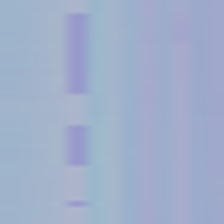

Advancing-Enclosing-Directing-Increasing Pressure-Accelerating-s01_smiley_t1604.png


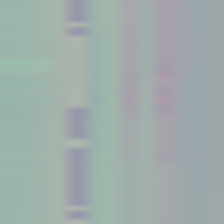

Enclosing-Increasing Pressure-Decelerating-s01_smiley_t3712.png


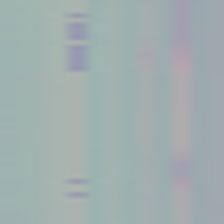

Advancing-Decreasing Pressure-Decelerating-s02_smiley_t1607.png


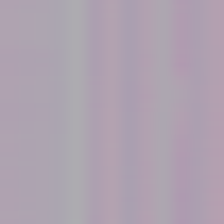

Descending-Increasing Pressure-Accelerating-s02_smiley_t2911.png


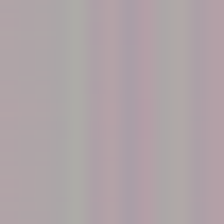

Spreading-Directing-Increasing Pressure-Accelerating-s03_smiley_t1134.png


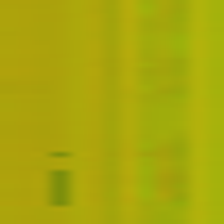

Enclosing-Increasing Pressure-Accelerating-s03_smiley_t1417.png


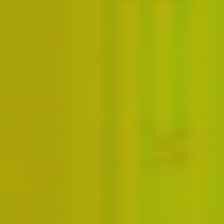

Enclosing-Increasing Pressure-Decelerating-s04_smiley_t1151.png


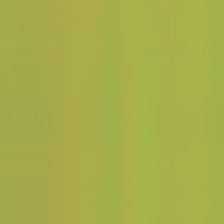

Enclosing-Descending-Directing-Increasing Pressure-Decelerating-s04_smiley_t2733.png


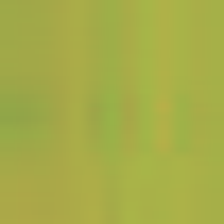

Enclosing-Indirecting-Increasing Pressure-Accelerating-s05_smiley_t2235.png


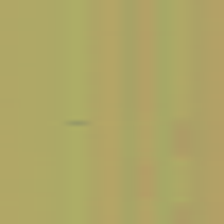

-s01_smiley_t2528.png


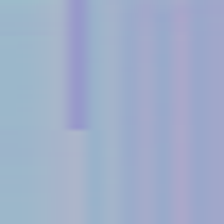

Spreading-Indirecting-Increasing Pressure-Accelerating-s03_smiley_t2239.png


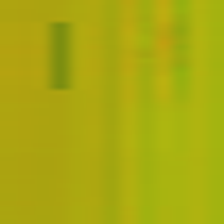

In [80]:
change_data_to_image(train_df, 50, '/project/ai901504-ai0004/501641_Big/week7/jeang_tvphoto/train')

## Model

In [81]:
def get_labels_from_fname(fname):
    stem = Path(fname).stem
    return stem.split('-')[:-1]

multilabel_datablock = DataBlock(
    blocks=(ImageBlock, MultiCategoryBlock),
    get_items=get_image_files,
    splitter=RandomSplitter(0.2, seed=42),
    get_x=lambda x: x,
    get_y=get_labels_from_fname
)

train_path = '/project/ai901504-ai0004/501641_Big/week7/jeang_tvphoto/train'  # Folder containing images

dls = multilabel_datablock.dataloaders(train_path, bs=8)

print(len(dls.train.dataset), len(dls.valid.dataset))


284 70


In [82]:
x, y = dls.one_batch()

print("\nShape of input images (x):", x.shape)
print("Shape of labels (y):", y.shape)
print(f"\nFirst image in the batch (tensor):\n{x[0]}")
print(f"Labels for the first image:\n{y[0]}")



Shape of input images (x): torch.Size([8, 3, 224, 224])
Shape of labels (y): torch.Size([8, 13])

First image in the batch (tensor):
TensorImage([[[0.6784, 0.6784, 0.6784,  ..., 0.6431, 0.6431, 0.6431],
              [0.6784, 0.6784, 0.6784,  ..., 0.6431, 0.6431, 0.6431],
              [0.6784, 0.6784, 0.6784,  ..., 0.6431, 0.6431, 0.6431],
              ...,
              [0.6745, 0.6745, 0.6745,  ..., 0.6431, 0.6431, 0.6431],
              [0.6745, 0.6745, 0.6745,  ..., 0.6431, 0.6431, 0.6431],
              [0.6745, 0.6745, 0.6745,  ..., 0.6431, 0.6431, 0.6431]],

             [[0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6980, 0.6980],
              [0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6980, 0.6980],
              [0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6980, 0.6980],
              ...,
              [0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6980, 0.6980],
              [0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6980, 0.6980],
              [0.6392, 0.6392, 0.6392,  ..., 0.6980, 0.6

In [83]:
model = YOLO("yolo11x-cls.yaml")
model.model.model[10].linear = nn.Linear(in_features=1280, out_features=12, bias=True)

YOLO11x-cls summary: 176 layers, 29,637,064 parameters, 29,637,064 gradients, 112.0 GFLOPs


In [84]:
class WrappedModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        out = self.base_model(x)
        # ถ้า out เป็น tuple ให้เลือกเอา element แรก (มักจะเป็น prediction)
        if isinstance(out, tuple):
            out = out[0]
        return out

In [85]:
wrapped_model = WrappedModel(model.model.model)

In [87]:
learner = Learner(train_dls, wrapped_model)
learner.fit(4)

epoch,train_loss,valid_loss,time


ValueError: Target size (torch.Size([104])) must be the same as input size (torch.Size([96]))

In [ ]:
preds, targs = learner.get_preds(ds_idx=1)

In [ ]:
preds

In [ ]:
pred_labels = (preds > 0.5).float()
pred_labels

In [ ]:
targs

### Predict test

In [ ]:
def change_data_to_image_test(df, framerate, scaler, path_folder_save):
  os.makedirs(path_folder_save, exist_ok=True)

  meta_df = df[['subject', 'timestamp']]

  df_features = df.drop(['subject', 'timestamp', 'frame'])

  df_features = df_features.to_numpy()
  df_scaled = scaler.transform(df_features)

  global_min = df_scaled.min()
  global_max = df_scaled.max()
  df_scaled = ((df_scaled - global_min) / (global_max - global_min) * 255).astype(np.uint8)

  #calculate number of image from df
  num_rows = df_scaled.shape[0]
  num_image = num_rows // framerate

  for i in range(num_image):
    #Fixed length from df to create image
    start = i * framerate
    end = start + framerate

    #Get name
    subject = meta_df.row(start)[0] # Access elements using .row() and index
    time_stamp = meta_df.row(start)[1] # Access elements using .row() and index

    file_name = f"{subject}_{time_stamp}.png"

    data_image = df_scaled[start : end]
    data_image = data_image.reshape((framerate, 17, 3))

    img = Image.fromarray(data_image, mode='RGB')
    img = img.resize((224, 224))
    img.save(os.path.join(path_folder_save, file_name))

    if i % 100 == 0:
      display(img) # Use display() to show image in Colab

In [ ]:
change_data_to_image_test(test_df, 30, scaler, path_folder_save='/content/phototesting')

In [ ]:
# Your already trained dls
path = Path('/content/phototesting')

# Load test files (e.g., all files in test folder or subset)
test_files = get_image_files(path)  # or Path('/content/testfolder') if different folder

# Create test_dl using your existing dls
test_dl = dls.test_dl(test_files)

# Use your trained learner to get predictions
preds, _ = learner.get_preds(dl=test_dl)

In [ ]:
preds

In [ ]:
pred_labels = (preds > 0.5).float()
pred_labels

In [ ]:
pred_np = pred_labels.numpy()
df_preds = pd.DataFrame(pred_np, columns=class_names)

In [ ]:
test_df = pd.read_csv('/content/kaggle_competition/test.csv')

In [ ]:
merged_df = pd.concat([test_df[['Filename', 'Time']].reset_index(drop=True), df_preds], axis=1)

In [ ]:
merged_df.to_csv('/content/submission.csv')